In [1]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.crs import CRS
from rasterstats import zonal_stats

In [2]:
## Set up file paths
## project root is two levels above notebooks/raw_data_processing
PROJECT_ROOT = Path.cwd().parent.parent
SHAPEFILE = PROJECT_ROOT / 'data' / 'raw' / 'fsa_boundary' / 'gfsa000a11a_e.shp'
RASTER_PATH = PROJECT_ROOT / 'data' / 'raw' / 'uranium' / 'Canada - 250m - RAD - Equivalent Uranium eU - 2025_Aug.ERS'
SAVE_PATH = PROJECT_ROOT / 'data' / 'processed' / 'fsa_uranium.csv'
RADON_AVAILABILITY_PATH = PROJECT_ROOT / 'data' / 'processed' / 'radon-concentration-cleaned.csv'

Band count: 1
Dtype: ('float32',)
CRS: None
Resolution: (4000.0, 4000.0)
Nodata: -999999.0
Min: -999999.0
Max: 34.915615


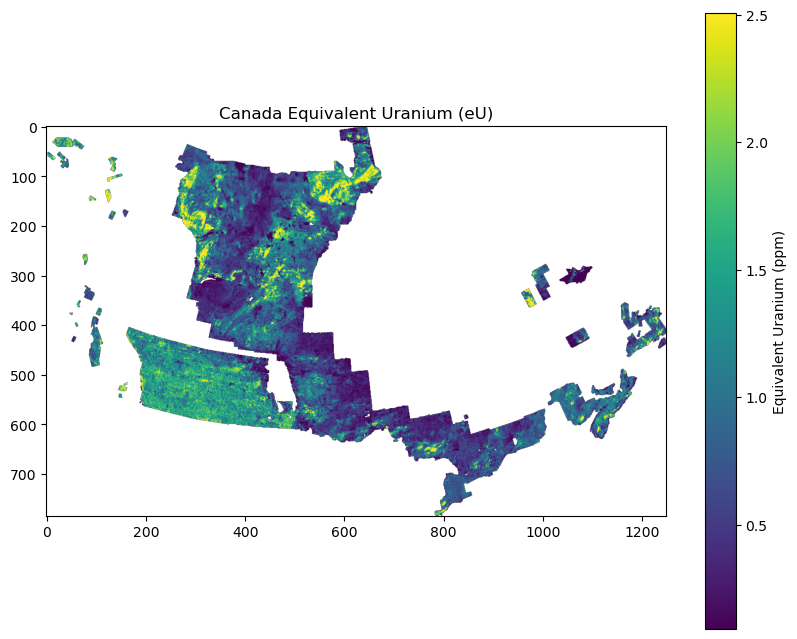

In [3]:
raster_path = RASTER_PATH

with rasterio.open(raster_path) as src:
    print("Band count:", src.count)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Nodata:", src.nodata)

    data = src.read(1)
    print("Min:", np.nanmin(data))
    print("Max:", np.nanmax(data))

data = np.where(data == -999999.0, np.nan, data)

with rasterio.open(raster_path) as src:
    profile = src.profile

profile.update(crs=CRS.from_epsg(3978))

vmin = np.nanpercentile(data, 2)
vmax = np.nanpercentile(data, 98)

plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(label="Equivalent Uranium (ppm)")
plt.title("Canada Equivalent Uranium (eU)")
plt.show()

In [4]:
fsas = gpd.read_file(SHAPEFILE)
fsas = fsas.to_crs(CRS.from_epsg(3978))
nodata = src.nodata

mean_stats = zonal_stats(fsas, raster_path, stats=['mean'], nodata=nodata)
max_stats = zonal_stats(fsas, raster_path, stats=['max'], nodata=nodata)
fsas['mean_uranium'] = [s['mean'] for s in mean_stats]
fsas['max_uranium'] = [s['max'] for s in max_stats]

fsa_uranium = fsas.copy()[['CFSAUID', 'mean_uranium', 'max_uranium']]
fsa_uranium.rename(columns={'CFSAUID': 'FSA'}, inplace=True)
fsa_uranium.head()
fsa_uranium.to_csv(SAVE_PATH, index=False)

In [5]:
## Count non-null values
len(fsa_uranium) - fsa_uranium.isna().sum()

FSA             1621
mean_uranium     945
max_uranium      945
dtype: int64

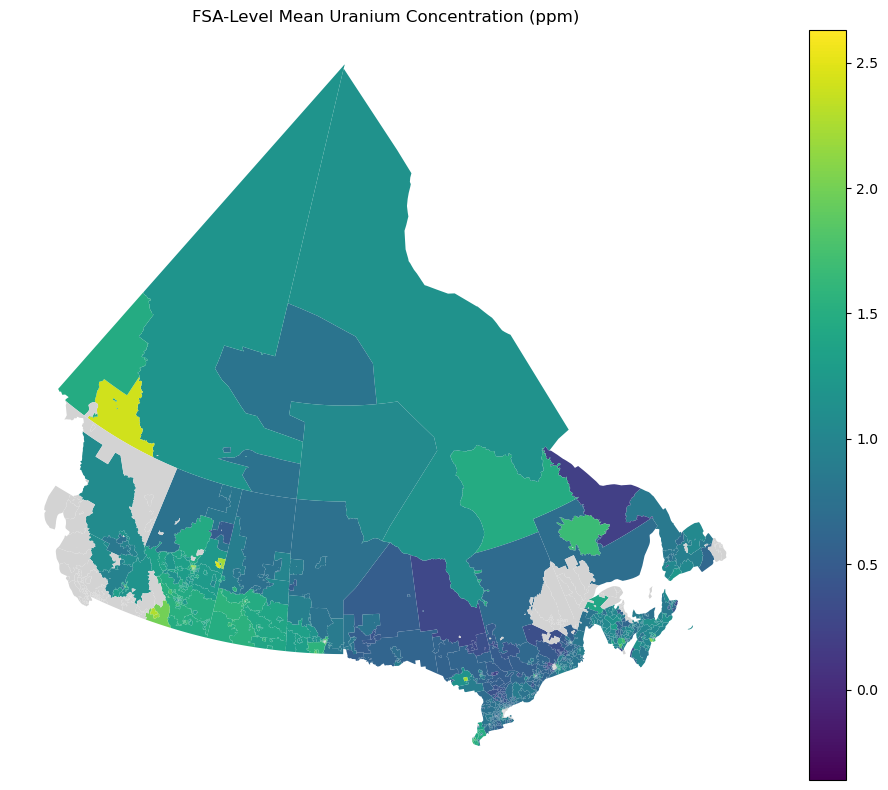

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

fsas.plot(
    column='mean_uranium',   # attribute to colour by
    cmap='viridis',         # matplotlib colormap
    linewidth=0.2,          
    ax=ax,
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },             
)

ax.set_title('FSA-Level Mean Uranium Concentration (ppm)')
ax.set_axis_off()           
plt.tight_layout()
plt.show()

In [7]:
fsa_relevant = pd.read_csv(RADON_AVAILABILITY_PATH)[['FSA']]
fsa_uranium = fsa_uranium[fsa_uranium['FSA'].isin(fsa_relevant['FSA'])]
fsa_uranium.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1014 entries, 0 to 1620
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FSA           1014 non-null   object 
 1   mean_uranium  666 non-null    float64
 2   max_uranium   666 non-null    float64
dtypes: float64(2), object(1)
memory usage: 31.7+ KB
